# Config

In [14]:
'''#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)
'''

'#MOana specific\nimport os, subprocess\nprint("PID:", os.getpid())\nprint("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))\nprint("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())\nprint(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)\n'

In [15]:
#MOANA ONLY
'''
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
'''

'\n#os.environ["CUDA_VISIBLE_DEVICES"] = "1"\n#check for errors\nos.environ["CUDA_LAUNCH_BLOCKING"] = "1"\n'

In [16]:
import time

_timers = {}

def timer_start(name="default"):
    _timers[name] = time.perf_counter()

def timer_end(name="default"):
    dt = time.perf_counter() - _timers.pop(name)
    print(f"[{name}] {dt:.2f}s")
    return dt
timer_start()

In [1]:
# Cell 0 — CONFIG
#case
case_name = "402_Hide_n_seek_sw07"
experiment = "v_02"
asset_name = f"{case_name}_{experiment}"
import json
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir
)

print("project_root:", project_root)
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")

set_case(case_name, experiment)

case_dir_ = case_dir()
source_dir_ = source_dir()
query_dir_ = query_dir()
masks_dir = sam3_masks_dir()
# These two are the PARENT stage folders. Each recon's own frame set now lives in a
# beat-keyed subfolder of them, handed out by build_recon_requests as job["frames_dir"].
frames_for_cam_poses = frames_for_cam_poses_dir()

frames_for_recon = frames_for_recon_dir()
VGGT_O_output_dir = vggt_o_output_dir()#used until 15 aug
ply_dir_ = ply_dir()
reg_dir_ = reg_dir()
csv_path_GPS = csv_path_gps()
csv_path_pose_ = csv_path_pose()

FRAME_NAME_FMT = "{:04d}.jpg"
# video loading
from Two2D.B_video_processing import video_fps
# Auto-find the video in 010_source
videos = list(source_dir_.glob("*.mp4"))
print(source_dir_)
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

project_root: /workspace/project
/workspace/project True
/workspace/project/Data/402_Hide_n_seek_sw07/010_source
Case    : 402_Hide_n_seek_sw07
Video   : VID_20260815_165930783.mp4
video fps: 30.000
total_frames 7655


In [2]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": False,
    "FRAME_SELECTION": True,
    "RECON_CAM_POSES": False,
    "RECON_3D": False,
    "GOOGLE_MAP": False,
    "BEV_MAP" : True,
    "PROJECTION_MAP": False,
    "MAKE_MOVIE": False,
    "MAKE_MOVIE_CUTS" : False,
    "MASK_OVERLAYS": False ,
    "PHYSICS_OVERLAYS" : False,
    "MULTICAM" : False
}
MENU_KEYS = {"TRACKING","RECON_CAM_POSES", "RECON_3D",
                          "GOOGLE_MAP", "BEV_MAP" , "PROJECTION_MAP", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

In [3]:
#2d ANALYSIS - JUST GPS now!
from D_2d_analysis import analysis_2D
analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
print(analysis_2d_for_decisions)

{'GPS_signal': 'no'}


# AI First Pass
## Gem, vid to text

In [20]:
#turn a video into a text description
if flags["VID_TO_TEXT"] == True:
    from Two2D.A_gemini_v02 import gemini_vid_to_text
    gem_summaries = gemini_vid_to_text(video_path, case_name, query_dir())
else:
    print("Cell disabled")

re_caching video
Here is a detailed summary of the video:

From 00:00 to 00:33, the person filming counts to 10 to start a game of hide and seek.

From 00:33 to 01:05, the seeker walks around the garden and finds the first person hiding behind a tree.

From 01:05 to 01:37, the seeker continues searching and finds the second person hiding behind a bush.

From 01:37 to 02:08, the seeker continues searching and finds the third person hiding behind a wooden gate.

From 02:08 to 02:35, the seeker finds the fourth person hiding behind a bin, and then the fifth person hiding behind a brick wall.

From 02:35 to 04:16, the seeker goes through a gate to the driveway and finds the last three people hiding behind a bush.
[gemini-diag] summary: prompt_feedback=None
[gemini-diag] summary: candidate[0].finish_reason=FinishReason.STOP
[gemini-diag] summary: candidate[0].safety_ratings=None
The tree is visible from 00:36 to 00:40 and again from 00:54 to 01:05.

The bush in the garden is visible from 01

## Producer 1

In [4]:
Question = "Make a video summary of this video and show where each person was hiding"

In [27]:
#PRODUCER DRAFT 1
from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft1
prompt = build_producer_prompt_draft1(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt, mode ="draft")

[07:40:36 +  0.00s] run_producer_agent: start
[07:40:36 +  0.00s] thread: start
[07:40:36 +  0.00s] event loop: created
[07:40:36 +  0.00s] query: start
[07:41:27 + 50.64s] turn 1 usage (claude-sonnet-5): in=2 out=5 cache_write=0 cache_read=16675
[07:41:27 + 50.64s] turn 1 content blocks: ['ThinkingBlock']
[07:41:27 + 50.64s] thinking:
I'm drafting the paper edit JSON, structuring beats around an opening establisher of the counting scene, each hiding-spot find as an event action, and a map beat showing the hiding locations since geography is central to this story's brief.

I'm sequencing the finds: person behind the tree around 00:54-01:05, person at the blue bushes around 01:22-01:37, and person at the wooden gate starting 01:41, keeping each clip under the 25-second window limit.

Continuing through the remaining finds, I'm mapping the bin discovery at 02:08-02:13, the brick wall catch at 02:15-02:35, and then splitting the final long sequence since the full 03:38-04:11 span exceeds 

In [5]:
# DRAFT TIDY UP
# Re-run this cell on its own to regenerate the HTML/flags after editing and correct mistakes
import importlib
import json
import render_paper_edit
importlib.reload(render_paper_edit)
from render_paper_edit import render_and_save, derive_and_save_flags, paper_edit_path
restart = True
if restart == True:
    #2d ANALYSIS - JUST GPS now!
    from D_2d_analysis import analysis_2D
    analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
    print(analysis_2d_for_decisions)

try:
    paper_edit_json_path  # from run_producer_agent, if the kernel still has it
except NameError:
    paper_edit_json_path = paper_edit_path()

html_path = render_and_save(paper_edit_json_path)
print(f"\n=== Rendered HTML ===\n  {html_path}")

flags_path = derive_and_save_flags(
    paper_edit_json_path, producer_flags.keys(), fps=fps,
    gps_signal=analysis_2d_for_decisions.get("GPS_signal"),
)
producer_output_flags = json.loads(flags_path.read_text(encoding="utf-8"))
flags.update(producer_output_flags)  # Producer owns MENU_KEYS; the rest stay operator-set
print(f"\n=== Derived flags (from {flags_path.name}) ===")
print(json.dumps(producer_output_flags, indent=2))

{'GPS_signal': 'no'}

=== Rendered HTML ===
  /workspace/project/Data/402_Hide_n_seek_sw07/012_agent_p_output/v_02/402_Hide_n_seek_sw07_draft_paper_edit.html

=== Derived flags (from 402_Hide_n_seek_sw07_draft_flags.json) ===
{
  "TRACKING": true,
  "RECON_CAM_POSES": true,
  "RECON_3D": false,
  "GOOGLE_MAP": false,
  "BEV_MAP": true,
  "PROJECTION_MAP": false,
  "MASK_OVERLAYS": false,
  "MULTICAM": false
}


# Tracking

In [6]:
# TRACKING SAM3 PIPELINE

if flags["TRACKING"]:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3
  
    analysis_2d_for_decisions.update (track_subject_sam3(video_path)) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)
else:
    print("Cell disabled")

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


here
accessing data
defaultdict(<class 'list'>, {})
initialising tracking (local SAM3)


/workspace/project/Models/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/vscode/.local/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-08-20 08:24:53,725 372760 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-08-20 08:24:53,727 372760 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-08-20 08:24:53,727 372760 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-08-20 08:25:03,024 372760 sam3_vid

[local SAM3] model loaded in 13.1s
[person] requested 54-65s -> keyframe-aligned start frame 1620


frame loading (OpenCV) [rank=0]: 100%|██████████| 335/335 [00:01<00:00, 233.54it/s]
INFO 2026-08-20 08:25:19,689 372760 sam3_base_predictor.py: 146: started new session 2a5b6d02-8156-4ad3-8727-995b4f5dd211
propagate_in_video: 100%|██████████| 335/335 [01:12<00:00,  4.62it/s]
INFO 2026-08-20 08:26:33,830 372760 sam3_base_predictor.py: 305: propagation ended in session 2a5b6d02-8156-4ad3-8727-995b4f5dd211
INFO 2026-08-20 08:26:34,188 372760 sam3_base_predictor.py: 409: removed session 2a5b6d02-8156-4ad3-8727-995b4f5dd211


...

[person] requested 226-234s -> keyframe-aligned start frame 6750


frame loading (OpenCV) [rank=0]: 100%|██████████| 264/264 [00:00<00:00, 294.00it/s]
INFO 2026-08-20 08:36:29,845 372760 sam3_base_predictor.py: 146: started new session f8466c46-f41c-4aa7-a809-3c0fced43557
propagate_in_video: 100%|██████████| 264/264 [01:33<00:00,  2.83it/s]
INFO 2026-08-20 08:38:04,213 372760 sam3_base_predictor.py: 305: propagation ended in session f8466c46-f41c-4aa7-a809-3c0fced43557
INFO 2026-08-20 08:38:04,409 372760 sam3_base_predictor.py: 409: removed session f8466c46-f41c-4aa7-a809-3c0fced43557


[person] requested 241-252s -> keyframe-aligned start frame 7200


frame loading (OpenCV) [rank=0]: 100%|██████████| 353/353 [00:01<00:00, 295.28it/s]
INFO 2026-08-20 08:38:14,119 372760 sam3_base_predictor.py: 146: started new session a3cde242-d0c5-47c2-a2ae-c61b02fcdbc2
propagate_in_video: 100%|██████████| 353/353 [01:50<00:00,  3.20it/s]
INFO 2026-08-20 08:40:04,823 372760 sam3_base_predictor.py: 305: propagation ended in session a3cde242-d0c5-47c2-a2ae-c61b02fcdbc2
INFO 2026-08-20 08:40:05,021 372760 sam3_base_predictor.py: 409: removed session a3cde242-d0c5-47c2-a2ae-c61b02fcdbc2


[local SAM3] released -- 4.72GiB still allocated
{'GPS_signal': 'no', 'person-01': {'Subject_frames_present': [1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954], 'subject_first_fra

In [7]:
pprint(analysis_2d_for_decisions)

Pretty printing has been turned OFF


In [8]:
#TRACKING SAM3 MANUAL controls
manual_sam = False
if manual_sam == True:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
    analysis_2d_for_decisions.update (run_sam3_manual(video_path, "person")) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)

In [27]:
#Rebuild tracking after restart 
restart = True
if restart == True:
    from D_2d_analysis import analysis_2d_from_masks, analysis_2d_gemvsSAM
    from render_paper_edit import paper_edit_path
    from pprint import pprint

    try:
        paper_edit_json_path  # from run_producer_agent, if the kernel still has it
    except NameError:
        paper_edit_json_path = paper_edit_path()

    #noun phrases form paper edit vs masks
    analysis_2d_for_decisions.update(analysis_2d_from_masks(paper_edit_json_path))  # non-person subjects, from mask folders
    #Gemini people from paper edit  VS sam csv
    pprint(analysis_2d_for_decisions)

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'GPS_signal': 'no',
 'person-01': {'Subject_frames_present': [1810,
                                          1811,
                                          1812,
                                          1813,
                                          1814,
                                          1815,
                                          1816,
                                          1817,
                                          1818,
                                          1819,
                                          1820,
                                          1821,
                                          1822,
                                          1823,
                                          1824,
                                          1825,
                                          1826,
                                          1827,
                                          1828,
                                          1829,
                   

In [10]:
 
print(analysis_2d_for_decisions)

{'GPS_signal': 'no', 'person-01': {'Subject_frames_present': [1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954], 'subject_first_frame': 1810, 'subject_last_frame': 1954, 'subject_d

In [12]:
#MATCHING GEM VS SAM
from A_Config import source_video_path
from Two2D.B_video_processing import video_dims
from Two2D.AX_gem_SAM_matcher import gem_person_targets_lookup
from Two2D.AY_claude_crop_matcher import write_masked_crops, match_tracks_to_descriptors
from D_2d_analysis import analysis_2d_gemvsSAM

_, _, fps = video_dims(source_video_path())

crops = write_masked_crops()                                  # eyeball these first
match_results = match_tracks_to_descriptors(crops_by_track=crops, fps=fps)

Gem_SAM_tracking = analysis_2d_gemvsSAM(
    gem_person_targets=gem_person_targets_lookup(fps),         # beat_ids only
    match_results=match_results,                               # crops, not box IoU
)

[person-01] 10 crop(s) from 145 masked frames
[person-02] 10 crop(s) from 33 masked frames
[person-03] 10 crop(s) from 79 masked frames
[person-04] 10 crop(s) from 129 masked frames
[person-05] 9 crop(s) from 9 masked frames
[person-06] 10 crop(s) from 236 masked frames
[person-07] 10 crop(s) from 236 masked frames
[person-08] 10 crop(s) from 13 masked frames
[person-09] 10 crop(s) from 137 masked frames
[person-10] 10 crop(s) from 99 masked frames
[person-11] 3 crop(s) from 3 masked frames
[person-12] 10 crop(s) from 15 masked frames
[person-13] 10 crop(s) from 94 masked frames
[person-14] 10 crop(s) from 149 masked frames
[person-15] 10 crop(s) from 42 masked frames
[person-16] 8 crop(s) from 9 masked frames (1 under 1500px, skipped)
[person-17] 10 crop(s) from 25 masked frames
[person-18] 6 crop(s) from 6 masked frames
[person-19] 10 crop(s) from 13 masked frames
[person-20] 9 crop(s) from 9 masked frames
[person-21] 10 crop(s) from 250 masked frames
[person-22] 10 crop(s) from 211 

# RECON
## Frame Selection

In [13]:
from render_paper_edit import build_recon_requests

recon_jobs = [j for j in build_recon_requests(fps=fps)
              if flags["RECON_CAM_POSES" if j["kind"] == "MAP" else "RECON_3D"]]

beat-07 MAP (RECON_CAM_POSES): 33-155s @ 29.972635042937284fps -> frames 989-4646
beat-10 MAP (RECON_CAM_POSES): 233-252s @ 29.972635042937284fps -> frames 6984-7553


In [6]:
#RECON JOBS - one per (beat, recon kind) the Producer asked for
# Replaces v06's single RECON_CAM_POSES window + single RECON_3D window. Every beat
# that asks for a recon gets its own: its own frame range, its own frames folder and
# its own recon folder, so several MAP and several EVENT recons live side by side.
# Max one of each kind per beat -- two recons of a kind means two beats.
# Each job dict is added to by the cells below; nothing here binds a global `recon`.
from render_paper_edit import build_recon_requests

recon_jobs = [j for j in build_recon_requests(fps=fps)
              if flags["RECON_CAM_POSES" if j["kind"] == "MAP" else "RECON_3D"]]

def jobs_of(kind=None, archetype=None, flag=None, beat_key=None):
    """The lookup every cell below uses instead of a single global recon variable.

    kind      -- which SOLVE this is: "MAP" (RECON_CAM_POSES, the camera track a
                 map is built from) or "EVENT" (RECON_3D, a moment of action).
    archetype -- what the BEAT is for: "MAP" for a beat that renders a map.
    These two are not the same thing -- a non-MAP beat can ask for either solve --
    so map rendering selects on archetype and physics work selects on kind.
    flag      -- something in the beat's own requested_flags, e.g. "BEV_MAP"."""
    return [j for j in recon_jobs
            if (kind is None or j["kind"] == kind)
            and (archetype is None or j["archetype"] == archetype)
            and (flag is None or flag in (j["beat"].get("requested_flags") or []))
            and (beat_key is None or j["beat_key"] == beat_key)]

print(f"{len(recon_jobs)} recon job(s)")
for job in recon_jobs:
    print(f"  {job['beat_key']:<10} {job['kind']:<6} frames {job['start_frame']}-{job['end_frame']}"
          f"  -> {job['recon_dir']}")


beat-07 MAP (RECON_CAM_POSES): 33-155s @ 30.0fps -> frames 990-4650
beat-10 MAP (RECON_CAM_POSES): 233-252s @ 30.0fps -> frames 6990-7560
2 recon job(s)
  beat-07    MAP    frames 990-4650  -> /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-07
  beat-10    MAP    frames 6990-7560  -> /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-10


In [15]:
print(flags)

{'VID_TO_TEXT': True, 'TRACKING': True, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': True, 'RECON_3D': False, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION_MAP': False, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': False, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}


In [16]:
#FRAME SELECTION - one frame set per recon job
# Same capacity/interval maths as v06, applied per job instead of once for the whole
# video: each beat's own window is thinned to `capacity` frames.
if flags["FRAME_SELECTION"] == True:
    from Two2D.B_video_processing import image_sequencer

    capacity  = 200      # frames one recon can hold
    window    = fps/2    # search window for sharpness
    min_sharp = 0.0      # raise this after inspecting selection_log.json

    for job in recon_jobs:
        span     = job["end_frame"] - job["start_frame"]
        skip     = (span + capacity - 1) // capacity     # frames to skip between samples
        interval = skip / fps                            # image_sequencer wants seconds
        print(f"{job['beat_key']} {job['kind']}: {span} frames, interval {skip}")

        results = image_sequencer(
            video_path    = str(video_path),
            output_dir    = str(job["frames_dir"]),
            interval_sec  = interval,
            search_window = window,
            min_sharpness = min_sharp,
            start_frame   = job["start_frame"],
            end_frame     = job["end_frame"],
        )
        print(f"  {len(results)} frames written to {job['frames_dir']}")
else:
    print("Cell disabled")


beat-07 MAP: 3657 frames, interval 19
Window  : clamped from ±14.986317521468642 to ±9 (half interval)
Video   : VID_20260815_165930783.mp4
          30 fps · 7655 frames · 255.4s
Range   : frames 989-4646 (3657 frames)
Sampling: every 19 frames (0.6339115654256477s) → 193 candidates
Window  : ±9 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 3657/3657 [00:13<00:00, 266.96fr/s]


Selected: 193 frames  (144 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 3657/3657 [00:08<00:00, 439.15fr/s]


Log     : /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_02/beat-07/selection_log.json
Sharpness (at 25% res): min 174 · mean 5229 · max 18420
  2 frames written to /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_02/beat-07
beat-10 MAP: 569 frames, interval 3
Window  : clamped from ±14.986317521468642 to ±1 (half interval)
Video   : VID_20260815_165930783.mp4
          30 fps · 7655 frames · 255.4s
Range   : frames 6984-7553 (569 frames)
Sampling: every 3 frames (0.10009129980404964s) → 190 candidates
Window  : ±1 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 569/569 [00:02<00:00, 270.19fr/s]


Selected: 190 frames  (48 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 569/569 [00:03<00:00, 186.16fr/s]


Log     : /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_02/beat-10/selection_log.json
Sharpness (at 25% res): min 96 · mean 2000 · max 10440
  2 frames written to /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_02/beat-10


In [17]:
print(frames_for_cam_poses_dir())

/workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_02


In [18]:
#MANUAL FRAME SELECTION - one frame set per recon job
manual_frames= False
if manual_frames == True:
    # Same capacity/interval maths as v06, applied per job instead of once for the whole
    # video: each beat's own window is thinned to `capacity` frames.

    from Two2D.B_video_processing import image_sequencer

    capacity  = 650      # frames one recon can hold
    window    = fps/2    # search window for sharpness
    min_sharp = 0.0      # raise this after inspecting selection_log.json

    span= 7581-0
    skip     = (span + capacity - 1) // capacity     # frames to skip between samples
    interval = skip / fps  
    output_dir    = str(frames_for_cam_poses_dir())
    results = image_sequencer(
    video_path    = str(video_path),
    output_dir    = output_dir,
    interval_sec  = interval,
    search_window = window,
    min_sharpness = min_sharp,
    start_frame   = 0,
    end_frame     = 7581,
    )
    print(output_dir)
else:
    print("Cell disabled")

Cell disabled


In [19]:
print(masks_dir)

/workspace/project/Data/402_Hide_n_seek_sw07/015_SAM3_masks/v_02


In [20]:
#mask checker ALL IN ONE
# MAP beats (frames mode): masks exist only on the ~200 recon frames, spread over the
# whole window. video_overlay_edit would cut the SOURCE video first-to-last masked
# frame -- a 4-minute clip that's ~99% unmasked, plus it raises on _sam_id_shots.
# mask_check_map_beats builds the video from the recon frames instead, so every frame
# carries its mask. Zero-arg: resolves its own masks + recon frames, no cell order.
mask_check = True
if mask_check == True:
    from Two2D.W_video_editor import mask_check_map_beats
    for p in mask_check_map_beats():
        print(p)


beat-07 MAP (RECON_CAM_POSES): 33-155s @ 30.0fps -> frames 990-4650
beat-10 MAP (RECON_CAM_POSES): 233-252s @ 30.0fps -> frames 6990-7560
skipped _id_crops: No frame-numbered mask PNGs in any of [PosixPath('/workspace/project/Data/402_Hide_n_seek_sw07/015_SAM3_masks/v_02/_id_crops')].
skipped _sam_id_shots: No frame-numbered mask PNGs in any of [PosixPath('/workspace/project/Data/402_Hide_n_seek_sw07/015_SAM3_masks/v_02/_sam_id_shots')].


beat-07_person_mask_check.mp4: 193 recon frames, 74 masks (38% of frames carry one)
    person-01                       7 masks
    person-02                       1 masks
    person-03                       4 masks
    person-04                       7 masks
    person-05                       0 masks
    person-06                      13 masks
    person-07                      12 masks
    person-08                       1 masks
    person-09                       5 masks
    person-10                       5 masks
    person-11                       0 masks
    person-12                       1 masks
    person-13                       7 masks
    person-14                       7 masks
    person-15                       3 masks
    person-16                       1 masks
    person-17                       0 masks
    person-18                       0 masks
    person-19                       0 masks
    person-20                       0 masks
    person-21                       

In [21]:
#mask checker (overlays) - VID
mask_check = False
if mask_check ==True:
    
    print(masks_dir)
    from Two2D.W_video_editor import video_overlay_edit
    for i, mask in enumerate(p for p in masks_dir.iterdir() if p.is_dir()):
        video = video_overlay_edit(video_path, mask,  name = f"hidenseek_ms7_v1{mask.name}")
    

## VGGT OMEGA
### one solve per recon job

In [7]:
import torch, gc; gc.collect(); torch.cuda.empty_cache()

In [8]:
print(torch.cuda.memory_allocated()/2**30, torch.cuda.memory_reserved()/2**30)


0.0 0.0


In [9]:
#VGGT OMEGA - one solve per recon job
import gc, torch
gc.collect()
torch.cuda.empty_cache()
from run_models.E_VGGT_omega import run_vggt_omega

checkpoint = (project_root / "Models" / "vggt-omega" / "checkpoints"
              / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt")

# Several jobs means several full solves, so a re-run of this cell skips the ones
# already on disk rather than repeating every pass. Flip to True to force a re-solve.
rerun_existing = False

for job in recon_jobs:
    if not rerun_existing and (job["recon_dir"] / "predictions.npz").exists():
        print(f"skip {job['beat_key']} {job['kind']} -- predictions.npz already there")
        continue
    print(f"solving {job['beat_key']} {job['kind']} from {job['frames_dir']}")
    run_vggt_omega(
        image_dir        = str(job["frames_dir"]),
        output_dir       = job["recon_dir"],
        checkpoint_path  = str(checkpoint),
        vggt_omega_dir   = str(project_root / "Models" / "vggt-omega"),
        image_resolution = 512,
        conf_thres       = 20.0,
        max_points       = 0,
        show_cam         = True,
    )
    gc.collect()
    torch.cuda.empty_cache()


solving beat-07 MAP from /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_02/beat-07
193 frames  →  /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-07
GPU freed -- 0.01 GiB still allocated, 0.57 GiB reserved
Saved: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-07/predictions.npz
Saved: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-07/scene.glb
solving beat-10 MAP from /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_02/beat-10
190 frames  →  /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-10
GPU freed -- 0.01 GiB still allocated, 0.57 GiB reserved
Saved: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-10/predictions.npz
Saved: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-10/scene.glb


# POST RECON
## Processing

In [10]:
#LOAD VGGT_O recons for further processing - one per job
from Thr3D.F_post_recon_processing import Reconstruction, positions_to_frame_dict

def PRP(recon, frames):
    frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
    rows = [recon.frame_to_row[f] for f in frame_keys]
    extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
    intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)
    R = extrinsic[:, :3, :3]
    t = extrinsic[:, :3, 3]
    cam_poses = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
    cam_poses_model_dict = positions_to_frame_dict(cam_poses, frames)
    return cam_poses_model_dict

# Each job loads its OWN predictions.npz from its own recon_dir -- v06 loaded the
# EVENT recon from the MAP folder.
for job in recon_jobs:
    job["recon"] = Reconstruction.load(
        job["frames_dir"], job["recon_dir"] / "predictions.npz", FRAME_NAME_FMT)
    job["cam_poses_model"] = PRP(job["recon"], job["frames_dir"])
    print(f"{job['beat_key']} {job['kind']}: {len(job['cam_poses_model'])} camera poses")


beat-07 MAP: 193 camera poses
beat-10 MAP: 190 camera poses


In [11]:
#TRANSFORM CAMERA POSES VS GPS - per recon
# Every recon calibrates against GPS on its own: its own R/s/t and its own lat_0/lon_0
# origin. Everything lands in the same real-world frame, so lat/lons from different
# beats ARE comparable (unlike the raw model-space positions below).
# Source is anything but "RS_path" so the poses dict is used directly rather than being
# read as a RealityScan csv; the string doubles as the alignment chart's label.
if analysis_2d_for_decisions['GPS_signal'] == 'yes':
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations

    for job in recon_jobs:
        (job["cam_poses_real"], job["cam_latlons"], job["R_cw"], job["s_cw"],
         job["t_cw"], job["lat_0"], job["lon_0"]) = model_to_GPS_calibrated_locations(
            csv_path_GPS, job["cam_poses_model"], Source=f"VGGT_O {job['beat_key']}")
        print(f"{job['beat_key']}: {len(job['cam_latlons'])} lat/lons, "
              f"origin {job['lat_0']}, {job['lon_0']}")
else:
    print("Cell disabled")


Cell disabled


## Recon Visualisation

In [12]:
#Convert into model space and export into plys - one folder per recon
# Each recon's clouds go next to its own predictions.npz (recon_dir/ply) instead of a
# shared VGGT_O_output_dir/MAP|EVENT folder, so two beats can't overwrite each other.
# n.b. this translates to the beginning of the camera track solve, then re-translates
# to that recon's own cam 0 space.
for job in recon_jobs:
    ext = job["recon"].preds["extrinsic"][0].clone()
    job["ext"]     = ext            # this recon's cam0 view, reused by the BEV/projection cells
    job["ply_dir"] = job["recon_dir"] / "ply"
    _ = job["recon"].VGGT_O_preds_to_ply_export(job["ply_dir"],
                                                R=ext[:, 0:3],
                                                t=ext[:, 3],
                                                s=1)
    print(f"{job['beat_key']} {job['kind']} -> {job['ply_dir']}")


beat-07 MAP -> /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-07/ply
beat-10 MAP -> /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-10/ply


In [13]:
# Cell — PLY visualisation, one per recon
import importlib
import F_cut3r_vis; importlib.reload(F_cut3r_vis)
from F_cut3r_vis import visualise_cut3r

for job in recon_jobs:
    print(f"{job['beat_key']} {job['kind']}: {job['recon_dir']}")
    visualise_cut3r(job["recon_dir"])


beat-07 MAP: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-07
Found 193 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

beat-10 MAP: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_02/beat-10
Found 190 PLY files


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

In [14]:
#cutr point cloud render
render_PC = False
if  flags["RECON_3D"] == True and render_PC == True:
    visualisation_dir = case_dir   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   

## ANALYSIS 3D

In [29]:
#depth confidence statistics - per recon
from C_CSV_report import add_to_report

for job in recon_jobs:
    conf = job["recon"].preds["depth_conf"].cpu().numpy()
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print("min, max confidence", conf.min(), conf.max())
    print("frames, y, x", conf.shape)
    print("confidence percentiles", np.percentile(conf, [5, 25, 50, 75, 95]))

    # add_to_report rows are overwrite-by-key, so each recon's numbers carry its own
    # beat key -- otherwise only the last job's would survive in the CSV.
    tag = f"{job['beat_key']} {job['kind']}"
    add_to_report({
        f"Depth Confidence (min) [{tag}]"        : conf.min(),
        f"Depth Confidence (max) [{tag}]"        : conf.max(),
        f"Depth Confidence (mean) [{tag}]"       : conf.mean(),
        f"Depth Confidence percentiles [{tag}]"  : np.percentile(conf, [5, 25, 50, 75, 95]),
    })


--- beat-07 MAP ---
min, max confidence 1.0000002 38.21173
frames, y, x (193, 384, 688)
confidence percentiles [ 1.2425954   2.7913872   4.37550735  6.35265255 11.63816357]
--- beat-10 MAP ---
min, max confidence 1.0000004 29.253948
frames, y, x (190, 384, 688)
confidence percentiles [1.18060133 3.85371041 5.78063536 7.60747302 9.63689041]


## no gps

In [40]:
print(analysis_2d_for_decisions.keys())

dict_keys(['GPS_signal', 'person-01', 'person-02', 'person-03', 'person-04', 'person-05', 'person-06', 'person-07', 'person-08', 'person-09', 'person-10', 'person-11', 'person-12', 'person-13', 'person-14', 'person-15', 'person-16', 'person-17', 'person-18', 'person-19', 'person-20', 'person-21', 'person-22', 'person-23', 'person-24'])


In [30]:
#multi subject positioning - NO GPS - per recon
# Positions come out in each recon's OWN arbitrary model space (its own scale and
# origin), so they stay on the job. Two jobs' positions are not comparable and must
# not be merged -- only the GPS path below puts them in a shared frame.
# A subject whose masks never land in this recon's frames simply drops out of its dict.
if analysis_2d_for_decisions['GPS_signal'] == "no":
    from Q_subject_analysis import find_mask_centroids_in_model_space
    from pathlib import Path
    cv2.setLogLevel(0)

    for job in recon_jobs:
        subjects_positions = {}
        subjects_depth_std = {}
        for subject_slug, entry in analysis_2d_for_decisions.items():
            if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
                continue
            track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
            merged_SAMS = {}
            merged_std  = {}
            for track_dir in track_dirs:
                track_dir = Path(track_dir)
                centroids, frame_keys, depth_std_model = find_mask_centroids_in_model_space(
                    job["recon"], masks_dir = track_dir, RA=8, analyse=False
                )
                for fk, c, s in zip(frame_keys, centroids, depth_std_model):
                    if np.isfinite(np.asarray(c)).all(): #subject positions can be Nan
                        merged_SAMS[fk] = c
                        merged_std[fk]  = s
            if merged_SAMS:
                subjects_positions[subject_slug] = merged_SAMS
                subjects_depth_std[subject_slug] = merged_std
        job["subjects_positions"] = subjects_positions
        job["subjects_depth_std"] = subjects_depth_std
        print(f"{job['beat_key']} {job['kind']}: {list(subjects_positions)}")


/workspace/project/src/Q_subject_analysis.py:288: RuntimeWarning: invalid value encountered in divide
  u = _rolling(dense_u_sum) / weight_sums_R  # average x pos (image space, so u)
/workspace/project/src/Q_subject_analysis.py:292: RuntimeWarning: invalid value encountered in divide
  v = _rolling(dense_v_sum) / weight_sums_R  # average y pos (image space, so v)
/workspace/project/src/Q_subject_analysis.py:296: RuntimeWarning: invalid value encountered in divide
  centroid_depth = _rolling(dense_depth_sum) / weight_sums_R


nan


/workspace/project/src/Q_subject_analysis.py:309: RuntimeWarning: invalid value encountered in divide
  z_std = np.sqrt(z_var_R / weight_sums_R)


nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
beat-07 MAP: ['person-01', 'person-02', 'person-03', 'person-04', 'person-06', 'person-07', 'person-08', 'person-09', 'person-10', 'person-12', 'person-13', 'person-14', 'person-15', 'person-16']
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
beat-10 MAP: ['person-21', 'person-22', 'person-23', 'person-24']


In [47]:
print(recon_jobs[0].keys()
      )

dict_keys(['beat_key', 'beat_ids', 'order', 'archetype', 'kind', 'flag', 'start_frame', 'end_frame', 'frames_dir', 'recon_dir', 'beat', 'recon', 'cam_poses_model', 'ext', 'ply_dir', 'subjects_positions', 'subjects_depth_std', 'group_metrics', 'meetings'])


In [42]:
#for k, v in analysis_2d_for_decisions.items():
#    print(f"{k}: {v}")

for k, v in subjects_positions.items():
    print(f"{k}: {v}")

person-21: {7269: array([-0.95844572,  0.03015305,  0.29938079]), 7272: array([-0.97738704,  0.0349479 ,  0.27897713]), 7275: array([-0.977362  ,  0.04038627,  0.26469908]), 7279: array([-0.99345233,  0.04225422,  0.25927302]), 7280: array([-0.99550086,  0.04053307,  0.26474221]), 7285: array([-0.99436818,  0.0354472 ,  0.27193094]), 7287: array([-1.00101177,  0.03523914,  0.26817584]), 7290: array([-0.99833545,  0.03478341,  0.26896716]), 7293: array([-1.00879051,  0.0367306 ,  0.26855485]), 7296: array([-1.01621551,  0.03288937,  0.26292298]), 7299: array([-1.02539974,  0.03265202,  0.26187359]), 7302: array([-1.0381114 ,  0.03142206,  0.25253504]), 7305: array([-1.05399655,  0.03278092,  0.24238576]), 7308: array([-1.07661515,  0.03418789,  0.23819668]), 7311: array([-1.07918405,  0.03476006,  0.23254211]), 7313: array([-1.08935734,  0.03554132,  0.22694861]), 7317: array([-1.09164859,  0.03283458,  0.22885762]), 7320: array([-1.09714658,  0.037187  ,  0.22240684]), 7323: array([-1.

In [32]:
for job in recon_jobs:
    print(f"--- {job['beat_key']} {job['kind']} ---")
    for k, v in job.get("subjects_positions", {}).items():
        print(f"{k}: {v}")


--- beat-07 MAP ---
person-01: {1828: array([ 0.86597868,  0.15034821, -0.75065203]), 1844: array([ 0.8610764 ,  0.15248312, -0.75285616]), 1868: array([ 0.86155177,  0.14194658, -0.74013794]), 1887: array([ 0.86788916,  0.13868658, -0.74287752]), 1901: array([ 0.87185892,  0.13436741, -0.75799833]), 1920: array([ 0.87984233,  0.13795366, -0.74912422]), 1934: array([ 0.86800023,  0.13935427, -0.75197884])}
person-02: {1887: array([ 0.74009066,  0.14139953, -0.87130235])}
person-03: {2471: array([ 0.41784516, -0.07233951,  0.33690311]), 2490: array([0.17692612, 0.04724258, 0.09939987]), 2509: array([ 0.05107092,  0.0843581 , -0.03991195]), 2528: array([0.04563543, 0.08920354, 0.06991636])}
person-04: {2742: array([ 0.66200313, -0.0088449 ,  0.22892562]), 2756: array([ 0.66388749, -0.01938836,  0.23319335]), 2775: array([ 0.65483681, -0.02766873,  0.22362649]), 2850: array([ 0.6802479 , -0.09252832,  0.28175715]), 2870: array([ 0.67202638, -0.09335337,  0.27771322]), 2889: array([ 0.6791

## get the stats done
positions
speed 
direction

## MERGE INTO NON GPS

In [33]:
#METRIC and LAT LON processes spatial information about the recon and the subjects - per recon
# One transform solve per recon, against that recon's own GPS-calibrated camera
# track. Unlike the model-space cell above, the lat/lons that come out of here ARE in
# a shared frame across beats.
if analysis_2d_for_decisions["GPS_signal"] == "yes":
    from Q_subject_analysis import subject_to_metric_and_gps_space
    from Thr3D.G_transforms_alignments import  recon_to_recon_transform
    from pathlib import Path

    for job in recon_jobs:
        R_mw , s_mw, t_mw  = recon_to_recon_transform(job["recon"], job["cam_poses_real"])
        job["R_mw"], job["s_mw"], job["t_mw"] = R_mw, s_mw, t_mw

        subjects_real_pos = {}
        subjects_latlon   = {}
        for subject_slug, entry in analysis_2d_for_decisions.items():
            if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
                continue
            track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
            merged_real   = {}
            merged_latlon = []
            for track_dir in track_dirs:
                sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
                    job["recon"],
                    masks_dir        = str(Path(track_dir)),
                    lat_0=job["lat_0"], lon_0=job["lon_0"],
                    R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
                    )
                for fk, p in sub_pos_real_dict.items():
                    if np.isfinite(np.asarray(p)).all():
                        merged_real[fk] = p
                merged_latlon += list(sub_latlon)
            if merged_real:
                subjects_real_pos[subject_slug] = merged_real
                subjects_latlon[subject_slug]   = sorted(merged_latlon)
        job["subjects_real_pos"] = subjects_real_pos
        job["subjects_latlon"]   = subjects_latlon

        #MAKE PLYS of VGGT__O, scaled to metres -- kept beside (not on top of) the
        #model-space plys the export cell above wrote for this same recon.
        job["ply_real_dir"] = job["recon_dir"] / "ply_real"
        _ = job["recon"].VGGT_O_preds_to_ply_export(job["ply_real_dir"],
                                                    R=R_mw, t=t_mw, s=s_mw)
        print(f"{job['beat_key']}: {list(subjects_real_pos)} -> {job['ply_real_dir']}")
else:
     print("Cell disabled")


Cell disabled


In [34]:
for job in recon_jobs:
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print(job.get("subjects_real_pos") or job.get("subjects_positions"))


--- beat-07 MAP ---
{'person-01': {1828: array([ 0.86597868,  0.15034821, -0.75065203]), 1844: array([ 0.8610764 ,  0.15248312, -0.75285616]), 1868: array([ 0.86155177,  0.14194658, -0.74013794]), 1887: array([ 0.86788916,  0.13868658, -0.74287752]), 1901: array([ 0.87185892,  0.13436741, -0.75799833]), 1920: array([ 0.87984233,  0.13795366, -0.74912422]), 1934: array([ 0.86800023,  0.13935427, -0.75197884])}, 'person-02': {1887: array([ 0.74009066,  0.14139953, -0.87130235])}, 'person-03': {2471: array([ 0.41784516, -0.07233951,  0.33690311]), 2490: array([0.17692612, 0.04724258, 0.09939987]), 2509: array([ 0.05107092,  0.0843581 , -0.03991195]), 2528: array([0.04563543, 0.08920354, 0.06991636])}, 'person-04': {2742: array([ 0.66200313, -0.0088449 ,  0.22892562]), 2756: array([ 0.66388749, -0.01938836,  0.23319335]), 2775: array([ 0.65483681, -0.02766873,  0.22362649]), 2850: array([ 0.6802479 , -0.09252832,  0.28175715]), 2870: array([ 0.67202638, -0.09335337,  0.27771322]), 2889: ar

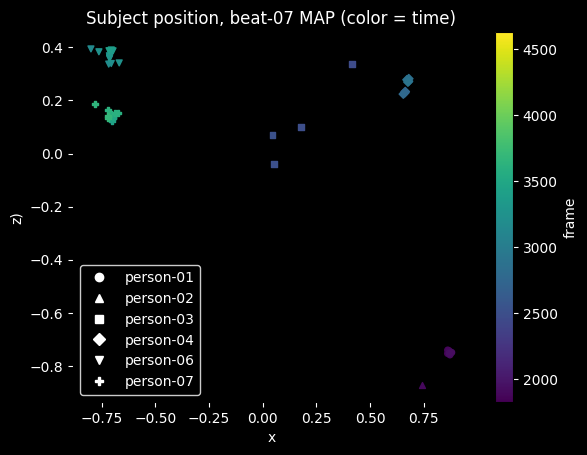

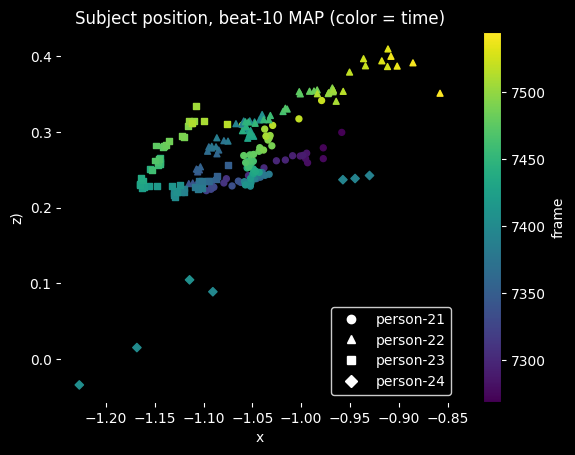

In [48]:
#graph postions 2d - NOT SURE HOW TO USE THIS! POINTLESS FOR THE REPORT!
# One figure per recon -- axes are that recon's own space, so plotting two on one set
# of axes would be meaningless.
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

markers = ["o", "^", "s", "D", "v", "P"]

for job in recon_jobs:
    subj = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    if not subj:
        print(f"{job['beat_key']} {job['kind']}: no subject positions")
        continue

    fig, ax = plt.subplots()
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    allf    = np.concatenate([np.array(sorted(d)) for d in subj.values()])
    handles = []
    for (slug, d), mk in zip(subj.items(), markers):
        frames = np.array(sorted(d))
        pts    = np.array([d[k] for k in frames])
        sc = ax.scatter(pts[:, 0], pts[:, 2], c=frames, cmap="viridis", marker=mk,
                        vmin=allf.min(), vmax=allf.max(), s=18)   # colour = frame number
        handles.append(Line2D([0], [0], marker=mk, ls="", color="white", label=slug))

    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("frame", color="white")
    cb.ax.yaxis.set_tick_params(color="white", labelcolor="white")

    ax.legend(handles=handles, labelcolor="white", facecolor="black", edgecolor="white")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.set_xlabel("x")
    ax.set_ylabel("z)")
    ax.set_title(f"Subject position, {job['beat_key']} {job['kind']} (color = time)")


In [36]:
if analysis_2d_for_decisions["GPS_signal"] == "yes":
    for job in recon_jobs:
        print(f"--- {job['beat_key']} ---")
        print(job.get("subjects_real_pos", {}).keys())


--- beat-07 MAP ---
{}
--- beat-10 MAP ---
{}


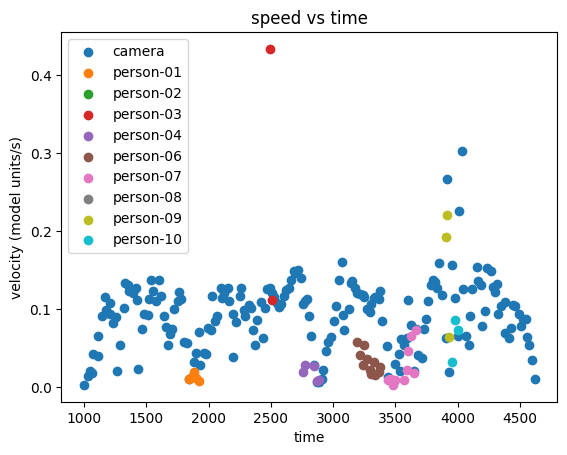

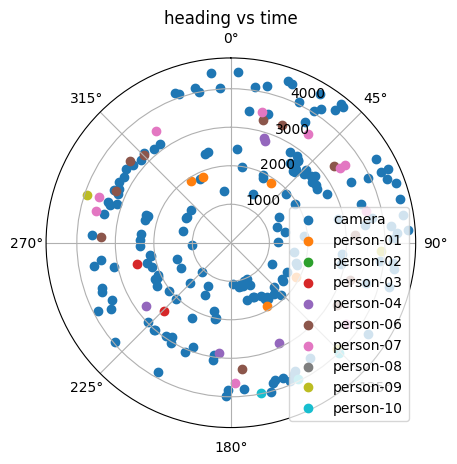

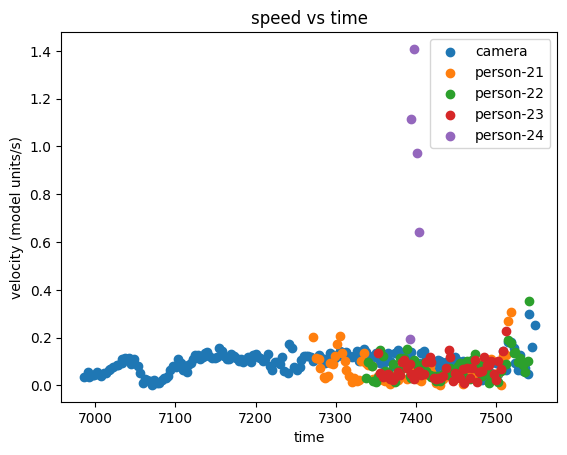

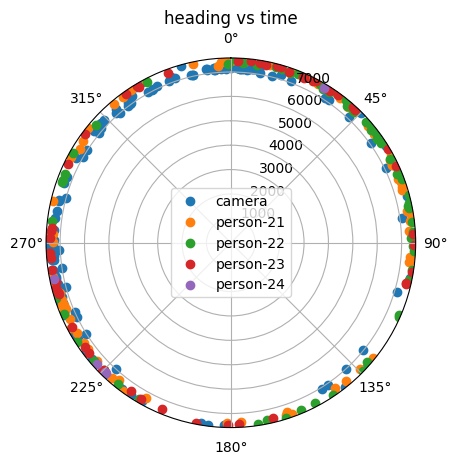

In [49]:
##3D Graphing and analysis METRIC OR NOT - per recon
# Speed/direction and meetings are both distance maths, so they run inside one recon's
# space. A requested pair is only measurable in a recon that actually saw both of them;
# pairs that split across two recons are reported as skipped rather than silently wrong.
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import  meeting_calculator
from render_paper_edit import build_meeting_requests

meeting_pairs = build_meeting_requests()   # [["person-1","person-2"], ["person-1","camera"]]

for job in recon_jobs:
    subjects = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    job["group_metrics"] = speed_direction(
        {"camera": job["cam_poses_model"], **subjects}, fps)

    meetings = {}
    for A_dict_entry, B_dict_entry in meeting_pairs:
        B_is_camera = B_dict_entry == "camera"
        if A_dict_entry not in subjects or (not B_is_camera and B_dict_entry not in subjects):
            print(f"{job['beat_key']}: skipping {A_dict_entry} vs {B_dict_entry} "
                  f"-- not both present in this recon")
            continue
        A_real_dict = subjects[A_dict_entry]
        B_real_dict = job["cam_poses_model"] if B_is_camera else subjects[B_dict_entry]

        meetings[(A_dict_entry, B_dict_entry)] = meeting_calculator(
            A_real_dict, A_dict_entry, B_real_dict, B_dict_entry,
            B_is_camera=B_is_camera)
    job["meetings"] = meetings
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print(meetings)


##TEMP TESTS

In [50]:
print(analysis_2d_for_decisions.keys())
print(analysis_2d_for_decisions["person-01"])

dict_keys(['GPS_signal', 'person-01', 'person-02', 'person-03', 'person-04', 'person-05', 'person-06', 'person-07', 'person-08', 'person-09', 'person-10', 'person-11', 'person-12', 'person-13', 'person-14', 'person-15', 'person-16', 'person-17', 'person-18', 'person-19', 'person-20', 'person-21', 'person-22', 'person-23', 'person-24'])
{'Subject_frames_present': [1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915

## this will be deleted

In [53]:
depth_intersection = False
if depth_intersection == True:
    #depth based intersections checker # TEMP
    #mask overlay sequence: person-1 (green) vs sword (magenta)
    from Two2D.W_video_editor import apply_mask_overlay, _load_mask_bool
    from A_Config import assets_dir, source_video_path
    from pathlib import Path
    import cv2
    A_slug, B_slug = "person-1", "the_large_sword-1"
    def _dirs(slug):
        e = analysis_2d_for_decisions[slug]
        return [Path(d) for d in (e.get("masks_dirs") or [e["masks_dir"]])]
    A_dir, B_dir = _dirs(A_slug)[0], _dirs(B_slug)[0]
    #sword is person 5
    B_dir = Path("/workspace/project/Data/304_met_multi_4/015_SAM3_masks/pipetest_01/person-3")   # the sword



    out_dir = assets_dir() / f"contact_check_{A_slug}_vs_{B_slug}"
    out_dir.mkdir(parents=True, exist_ok=True)

    frames = sorted(set(analysis_2d_for_decisions[A_slug]["Subject_frames_present"]) |
                    set(analysis_2d_for_decisions[B_slug]["Subject_frames_present"]))

    cap = cv2.VideoCapture(str(source_video_path()))
    for f in frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = cap.read()
        if not ret:
            continue
        for d, colour in ((A_dir, (0, 200, 0)), (B_dir, (200, 0, 200))):
            m = _load_mask_bool(d, f)
            if m is not None:
                frame = apply_mask_overlay(frame, m, color=colour)
        cv2.imwrite(str(out_dir / f"{f:04d}.png"), frame)
    cap.release()
    print(out_dir, len(frames), "frames")

# TOUCHING TEST
## Needs work  see PHYSICS - NEW FLAGS PLAN MULTI RECON 

In [55]:
# subject touching test
if depth_intersection == True:
    # Manual/WIP cell -- there's no rule yet for which recon a contact test belongs to,
    # so pick the job by hand (see the RECON JOBS cell for what's available).
    from Q_subject_analysis import contact_frames
    job = recon_jobs[0]
    res = contact_frames(job["recon"], A_dir, B_dir)

    r = res[386]          # your contact frame
    plt.plot(list(r["A_profile"]), list(r["A_profile"].values()), "o-", label="A")
    plt.plot(list(r["B_profile"]), list(r["B_profile"].values()), "o-", label="B")
    plt.xlabel("depthels from seam"); plt.ylabel("depth"); plt.legend()
    print(r["depth_gap"], r["fit_resid"], r["contact"])


# Rendering
## Point_cloud based

In [56]:
#projection map - one per beat that asked for one
# A projection map is a novel view of a RECON_3D, so it runs on the jobs whose beat
# requested PROJECTION_MAP. Each uses its own recon's cam0 view and its own frame set;
# main_idx is the middle frame of that set rather than a hardcoded number, which would
# only exist in one recon.
if flags["PROJECTION_MAP"] == True:
    from P_projection_mapping import projection_mapping_sequence
    from Two2D.B_video_processing import available_frames

    for job in jobs_of(flag="PROJECTION_MAP"):
        extra_indices = available_frames(job["frames_dir"], FRAME_NAME_FMT)
        print(f"{job['beat_key']}: {extra_indices}")
        job["projection_subject_positions"] = projection_mapping_sequence(
            recon         = job["recon"],
            main_idx      = extra_indices[len(extra_indices) // 2],
            extra_indices = extra_indices,
            masks_dir     = str(yolo_masks_dir),
            new_view      = job["ext"],
            confidence_threshold = 2,
        )
else:
    print("Cell disabled")


Cell disabled


# PRODUCER 2

In [57]:
print(analysis_2d_for_decisions)

{'GPS_signal': 'no', 'person-01': {'Subject_frames_present': [1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954], 'subject_first_frame': 1810, 'subject_last_frame': 1954, 'subject_d

In [58]:
#find the cut points
import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions)

PosixPath('/workspace/project/Data/402_Hide_n_seek_sw07/012_agent_p_output/v_02/402_Hide_n_seek_sw07_paper_edit_draft.json')

In [59]:
#run producer again
from producer_agent_execution import run_producer_agent, build_producer_prompt_revision

prompt = build_producer_prompt_revision(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt)

[09:54:51 +  0.00s] run_producer_agent: start
[09:54:51 +  0.00s] thread: start
[09:54:51 +  0.00s] event loop: created
[09:54:51 +  0.03s] query: start
[09:56:00 + 68.63s] turn 1 usage (claude-sonnet-5): in=2 out=5 cache_write=34226 cache_read=0
[09:56:00 + 68.63s] turn 1 content blocks: ['ThinkingBlock']
[09:56:00 + 68.63s] thinking:
I'm cross-checking the draft against the 2D tracking data, matching person-01 through person-24 results to the tracked subjects in beat-07 and beat-10, trying to figure out how the person IDs map across the two MAP sequences.

Looking at the timing for person-01 (frames 1810-1954, roughly 60-65 seconds), this falls within beat-07's search window rather than matching a specific gem_person_id directly. I'm realizing these person-01 through person-24 labels are actually SAM3 tracking outputs generated across each MAP's search window, not direct equivalents to the gem_person_id entries in the PEOPLE list -- meaning the same individual could appear as multipl

## Mapping

In [60]:
#make animated map -- one map per GOOGLE_MAP beat. Each writes its own image sequence
# to assets/map_frames_<beat_key> (the standard hand-off to the editor); gif/mp4 are
# optional extra exports of the same frames. Duration comes from the beat we pass in,
# so two MAP beats get two different-length animations instead of sharing one.
if flags["GOOGLE_MAP"] == True:
    import Rendering.R_map_animator

    for job in jobs_of(archetype="MAP", flag="GOOGLE_MAP"):
        subject_traces = [{"coords": latlons, "trail_color": "#e74c3c"}      #subjects
                          for latlons in job.get("subjects_latlon", {}).values()]
        Rendering.R_map_animator.main(
            traces = [
                {"coords": job["cam_latlons"], "trail_color": "#3498db"},     #cameras
                *subject_traces,
            ],
            api_key = api_key,
            beat    = job["beat"],
            gif = True,
            mp4 = None,
        )
else:
    print("Cell disabled")


Cell disabled


In [61]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)

In [62]:
#BEV SETUP - the frames each recon actually holds, per job
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from AA_cam_pose_sweeps import _render_bev_tiles
from Two2D.B_video_processing import available_frames

#Use this to project every frame in each recon
for job in recon_jobs:
    job["extra_indices"] = available_frames(job["frames_dir"], FRAME_NAME_FMT)
    print(f"{job['beat_key']} {job['kind']}: {len(job['extra_indices'])} frames")


beat-07 MAP: 193 frames
beat-10 MAP: 190 frames


In [63]:
#BEV HI RES - one BEV still per BEV_MAP beat
#BEV projection mapping of subject to a selected view
# BEV_tile_render_PM's default out_path is asset_name-based (one file for the whole
# case), so pass a beat-keyed path in. That also skips its own add_to_asset_list, so
# the beat-keyed asset row is logged here instead.
from A_Config import assets_dir, asset_name, to_report_path
from C_CSV_report import add_to_asset_list

for job in jobs_of(archetype="MAP", flag="BEV_MAP"):
    out_path = assets_dir() / f"{asset_name()}_BEV_tile_render_PM_{job['beat_key']}.png"
    BEV, job["new_view"], job["ortho_params"], job["BEV_path"] = BEV_tile_render_PM(
        job["recon"],
        job["extra_indices"],
        masks_dir = None,
        splat_radius = 1,
        confidence_threshold = 1.05,
        margin_frac = 0.05,
        out_path = out_path,
    )
    add_to_asset_list({f"BEV_tile_render_PM_{job['beat_key']}": to_report_path(job["BEV_path"])})
    print(f"{job['beat_key']}: {job['BEV_path']}")


min depth tensor(0.0173, device='cuda:0')
torch.Size([49724114, 3])
mins, maxes and ranges -3.5362536668777467 2.182156300544739 5.7184099674224855 -3.2128559768199922 1.9815040051937103 5.194359982013703
scale - original 1293.8378766672986
beat-07: /workspace/project/Data/402_Hide_n_seek_sw07/090_assets/402_Hide_n_seek_sw07_v_02_BEV_tile_render_PM_beat-07.png
min depth tensor(0.0340, device='cuda:0')
torch.Size([48694798, 3])
mins, maxes and ranges -3.8050633311271667 1.685088002681732 5.490151333808899 -1.269756281375885 2.3388311505317687 3.6085874319076536
scale - original 1567.7633597052554
beat-10: /workspace/project/Data/402_Hide_n_seek_sw07/090_assets/402_Hide_n_seek_sw07_v_02_BEV_tile_render_PM_beat-10.png


In [64]:
#TRACE OVERLAY Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#One animation per BEV_MAP beat, each over its own BEV still. n_frames comes from the beat
#we pass in (duration_seconds * fps), and frames land in bev_trace_frames_<beat_key>.
from P_trace_overlayer import BEV_trace_overlay

for job in jobs_of(archetype="MAP", flag="BEV_MAP"):
    BEV_trace_overlay(
        job["recon"],
        job["extra_indices"],
        job["new_view"],
        job["ortho_params"],
        subject_positions = job.get("subjects_real_pos") or job.get("subjects_positions") or {},
        bev_png_path      = job["BEV_path"],
        beat              = job["beat"],
    )


Skipping subject trace 'person-02' -- only 1 frame(s) overlap extra_indices.
Skipping subject trace 'person-08' -- only 1 frame(s) overlap extra_indices.
Skipping subject trace 'person-12' -- only 1 frame(s) overlap extra_indices.
Skipping subject trace 'person-16' -- only 1 frame(s) overlap extra_indices.
frame 0000 t_frac=0.0000 [camera] virtual_frame=989.0 pos_px=(735.2, 412.0)
frame 0000 t_frac=0.0000 [person-01] virtual_frame=989.0 pos_px=(915.3, 568.1)
frame 0000 t_frac=0.0000 [person-03] virtual_frame=989.0 pos_px=(822.1, 342.0)
frame 0000 t_frac=0.0000 [person-04] virtual_frame=989.0 pos_px=(873.1, 364.0)
frame 0000 t_frac=0.0000 [person-06] virtual_frame=989.0 pos_px=(569.1, 330.1)
frame 0000 t_frac=0.0000 [person-07] virtual_frame=989.0 pos_px=(588.9, 385.9)
frame 0000 t_frac=0.0000 [person-09] virtual_frame=989.0 pos_px=(562.0, 506.9)
frame 0000 t_frac=0.0000 [person-10] virtual_frame=989.0 pos_px=(575.7, 502.6)
frame 0000 t_frac=0.0000 [person-13] virtual_frame=989.0 pos_px

In [65]:
#Make the edited multimedia movie

import Two2D.W_video_editor
 
Two2D.W_video_editor.assemble_paper_edit(video_path)

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

PosixPath('/workspace/project/Data/402_Hide_n_seek_sw07/090_assets/402_Hide_n_seek_sw07_v_02_rough_cut.mp4')

In [67]:
from V_text_summary import gemini_final_report, gemini_cache_video
vid_path = assets_dir() / f"{asset_name()}_rough_cut.mp4"
cache =  gemini_cache_video(vid_path, assets_dir(), ttl="6000s")
gemini_final_report()

On August 15, 2026, at approximately 5:00 PM, a game of hide-and-seek was filmed in a residential backyard garden, focusing on a woman in a black t-shirt and sunglasses hiding behind a large tree.

The seeker found her crouching behind the tree trunk and foliage, exclaiming, "Caught you! You've been found!" as she smiled and showed peace signs to the camera. After being discovered, she stood near the patio furniture and watched as other players were found.

The subject traveled a net distance of 0.011 model units at a heading of 123.28 degrees, with her activity recorded from 17:00:31 to 17:03:16.
**00:00** [Seeker]: Okay everybody. Check us out. One, two, three, four, five, six, seven, eight, nine, ten. Ready or not, here I...

**00:20** [Seeker]: Oh.

**00:23** [Hider]: Hoo-hoo!

**00:24** [Seeker]: I can see a human.

**00:26** [Hider]: Hoo-hoo!

**00:28** [Seeker]: Ah, caught you! You've been found.

**00:32** [Hider]: I've been found.

**00:32** [Seeker]: Excellent. Okay.

**00:34

In [ ]:
timer_end()

In [ ]:
# Cell — Populate PowerPoint from CSV
import importlib

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))